In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import the refactored TrendAnalyzer
from soros_system.main import TrendAnalyzer
from soros_system.analysis.markov_vol_model import MarkovVolModel


# Define asset IDs and paths to your data
asset_ids = [
    'bitcoin', 'ethereum', 'solana', 'ripple'
    # Add more assets as needed
]

data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/'
btc_data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/bitcoin_candles.csv'
ssr_data_path='/Users/valter.rebelo/MissionControl/data/onchainData/BTC_SSR.csv'
markov_vol_model = MarkovVolModel.load_model_by_timestamp('20250325_144631')


analyzer = TrendAnalyzer(
    asset_ids=asset_ids,
     data_path=data_path,
     btc_data_path=btc_data_path,
     lookback_days='all',
     ssr_data_path=ssr_data_path,        
     markov_analyzer=markov_vol_model  
 )

# Analyze all assets
results = analyzer.analyze_multiple_assets()


Detected MarkovVolModel passed as markov_analyzer - using it for volatility analysis


Analyzing assets:   0%|          | 0/4 [00:00<?, ?it/s]

Classifying bitcoin:   0%|          | 0/1 [00:00<?, ?it/s]

Creating trend data for bitcoin:   0%|          | 0/2 [00:00<?, ?it/s]

Classifying ethereum:   0%|          | 0/1 [00:00<?, ?it/s]

...

Creating trend data for solana:   0%|          | 0/2 [00:00<?, ?it/s]

Classifying ripple:   0%|          | 0/1 [00:00<?, ?it/s]

Creating trend data for ripple:   0%|          | 0/2 [00:00<?, ?it/s]

Computing metrics:   0%|          | 0/4 [00:00<?, ?it/s]

Column overall_trend_BTC not found in data for bitcoin. Skipping BTC trend metrics calculation.


In [2]:
analyzer.ssr_handler.get_ssr_signal('2025-03-25')

1

In [3]:
analyzer.markov_vol_model.get_volatility_state('2025-03-29')

Date 2025-03-29 after model data range end 2025-03-24 00:00:00


'low'

In [4]:
analyzer.get_asset_processed_data('ripple')

,date,open,high,low,close,ripple_btc_open,ripple_btc_high,ripple_btc_low,ripple_btc,asset_id,...,MA365_ripple_btc,RoC365_ripple_btc,short_term_trend_BTC,medium_term_trend_BTC,long_term_trend_BTC,overall_trend_BTC,RSI_Signal_28_USD,RSI_Signal_28_BTC,returns_usd,returns_btc
0,2013-08-04,0.005874,0.005874,0.005874,0.005874,0.000056,0.000056,0.000056,0.000056,ripple,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-08-05,0.005653,0.005653,0.005653,0.005653,0.000053,0.000053,0.000053,0.000053,ripple,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.037669,-0.053021
2,2013-08-06,0.004669,0.004669,0.004669,0.004669,0.000044,0.000044,0.000044,0.000044,ripple,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.174030,-0.168411
3,2013-08-07,0.004486,0.004486,0.004486,0.004486,0.000042,0.000042,0.000042,0.000042,ripple,...,NaN,NaN,-2.0,NaN,NaN,NaN,NaN,NaN,-0.039155,-0.047346
4,2013-08-08,0.004196,0.004196,0.004196,0.004196,0.000041,0.000041,0.000041,0.000041,ripple,...,NaN,NaN,-2.0,NaN,NaN,NaN,NaN,NaN,-0.064761,-0.018031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4252,2025-03-26,2.450000,2.480000,2.340000,2.350000,0.000028,0.000028,0.000027,0.000027,ripple,...,0.000014,199.252688,-1.0,0.0,2.0,0.0,1.0,1.0,-0.040816,-0.034640
4253,2025-03-27,2.350000,2.390000,2.310000,2.340000,0.000027,0.000027,0.000027,0.000027,ripple,...,0.000014,204.217321,-2.0,0.0,2.0,0.0,1.0,1.0,-0.004255,-0.007292
4254,2025-03-28,2.340000,2.340000,2.160000,2.200000,0.000027,0.000027,0.000026,0.000026,ripple,...,0.000015,195.482071,-2.0,-1.0,0.0,-1.0,1.0,1.0,-0.059829,-0.027866
4255,2025-03-29,2.210000,2.220000,2.060000,2.140000,0.000026,0.000026,0.000025,0.000026,ripple,...,0.000015,186.992225,-2.0,-1.0,0.0,-1.0,-1.0,1.0,-0.027273,-0.007507


In [5]:
latest_trends = analyzer.get_latest_signals()
latest_trends

,ticker,asset_id,date,short_term_trend_USD,medium_term_trend_USD,long_term_trend_USD,overall_trend_USD,rsi_signal_28_USD,short_term_trend_BTC,medium_term_trend_BTC,long_term_trend_BTC,overall_trend_BTC,rsi_signal_28_BTC
0,BTC,bitcoin,2025-03-30,-2.0,-1.0,0.0,-1.0,-1.0,NaN,NaN,NaN,NaN,NaN
1,ETH,ethereum,2025-03-30,-2.0,-2.0,-2.0,-2.0,-1.0,-2.0,-2.0,-2.0,-2.0,-1.0
2,SOL,solana,2025-03-30,-2.0,-2.0,-2.0,-2.0,-1.0,-2.0,-2.0,-2.0,-2.0,-1.0
3,XRP,ripple,2025-03-30,-2.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0


In [6]:
# Get processed data for Cardano
eth_processed = analyzer.get_asset_processed_data('ethereum')
eth_processed  # See available columns including trend classifications

,date,open,high,low,close,ethereum_btc_open,ethereum_btc_high,ethereum_btc_low,ethereum_btc,asset_id,...,MA365_ethereum_btc,RoC365_ethereum_btc,short_term_trend_BTC,medium_term_trend_BTC,long_term_trend_BTC,overall_trend_BTC,RSI_Signal_28_USD,RSI_Signal_28_BTC,returns_usd,returns_btc
0,2015-08-07,2.830000,2.830000,2.830000,2.830000,0.010161,0.010161,0.010161,0.010161,ethereum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-08-08,1.330000,1.330000,1.330000,1.330000,0.005119,0.005119,0.005119,0.005119,ethereum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.530035,-0.496190
2,2015-08-09,1.008793,1.008793,1.008793,1.008793,0.003816,0.003816,0.003816,0.003816,ethereum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.241509,-0.254536
3,2015-08-10,0.687586,0.687586,0.687586,0.687586,0.002609,0.002609,0.002609,0.002609,ethereum,...,NaN,NaN,-2.0,NaN,NaN,NaN,NaN,NaN,-0.318407,-0.316442
4,2015-08-11,1.067000,1.067000,1.067000,1.067000,0.003954,0.003954,0.003954,0.003954,ethereum,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.551806,0.515637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3519,2025-03-26,2066.470000,2078.190000,1985.690000,2009.880000,0.023637,0.023544,0.023126,0.023112,ethereum,...,0.041039,-54.900661,-1.0,-2.0,-2.0,-2.0,-1.0,-1.0,-0.028386,-0.022129
3520,2025-03-27,2009.340000,2034.400000,1989.020000,2003.300000,0.023119,0.023178,0.023164,0.022967,ethereum,...,0.040963,-54.504916,-2.0,-2.0,-2.0,-2.0,-1.0,-1.0,-0.003274,-0.006313
3521,2025-03-28,2002.150000,2015.310000,1866.540000,1896.920000,0.022957,0.023032,0.022325,0.022486,ethereum,...,0.040887,-55.340206,-2.0,-2.0,-2.0,-2.0,-1.0,-1.0,-0.053102,-0.020910
3522,2025-03-29,1896.320000,1911.020000,1804.600000,1829.270000,0.022486,0.022605,0.022069,0.022125,ethereum,...,0.040810,-56.003656,-2.0,-2.0,-2.0,-2.0,-1.0,-1.0,-0.035663,-0.016068


In [7]:
analyzer.get_asset_information('ethereum')

{'asset_id': 'ethereum',
 'raw_data':            date         open         high          low        close  \
 0    2015-08-07     2.830000     2.830000     2.830000     2.830000   
 1    2015-08-08     1.330000     1.330000     1.330000     1.330000   
 2    2015-08-09     1.008793     1.008793     1.008793     1.008793   
 3    2015-08-10     0.687586     0.687586     0.687586     0.687586   
 4    2015-08-11     1.067000     1.067000     1.067000     1.067000   
 ...         ...          ...          ...          ...          ...   
 3519 2025-03-26  2066.470000  2078.190000  1985.690000  2009.880000   
 3520 2025-03-27  2009.340000  2034.400000  1989.020000  2003.300000   
 3521 2025-03-28  2002.150000  2015.310000  1866.540000  1896.920000   
 3522 2025-03-29  1896.320000  1911.020000  1804.600000  1829.270000   
 3523 2025-03-30  1827.770000  1847.220000  1782.690000  1805.340000   
 
       ethereum_btc_open  ethereum_btc_high  ethereum_btc_low  ethereum_btc  \
 0              0.

In [8]:
info = analyzer.get_asset_information('ethereum')
short_term_matrix = info.get('transition_matrix_usd_short_term')
medium_term_matrix = info.get('transition_matrix_usd_medium_term')
long_term_matrix = info.get('transition_matrix_usd_long_term')
overall_matrix = info.get('transition_matrix_usd_overall')

In [9]:
info = analyzer.get_asset_information('ethereum')
info.get('transition_matrix_usd')
trends_usd = info.get('consolidated_trend_metrics_usd')
positive_usd_trends = trends_usd[(trends_usd['Sortino'] > 0) & 
                         (trends_usd['Sharpe'] > 0) & 
                         (trends_usd['Return_Skew'] > 0) & 
                         (trends_usd['Avg_Return'] > 0) & 
                         (trends_usd['Median_Return'] > 0)]
positive_usd_trends
trends_btc = info.get('consolidated_trend_metrics_btc')
positive_btc_trends = trends_btc[(trends_btc['Sortino'] > 0) & 
                         (trends_btc['Sharpe'] > 0) & 
                         (trends_btc['Return_Skew'] > 0) & 
                         (trends_btc['Avg_Return'] > 0) &   
                         (trends_btc['Median_Return'] > 0)]
positive_btc_trends

# Get the processed data to analyze concurrent trends
solana_data = analyzer.get_asset_processed_data('ethereum')

# Extract positive trend conditions for USD
positive_usd_trend_conditions = []
for _, row in positive_usd_trends.iterrows():
    term = row['Term'].lower().replace(' ', '_')
    trend = row['Trend']
    positive_usd_trend_conditions.append((f"{term}_trend_USD", trend))

# Extract positive trend conditions for BTC
positive_btc_trend_conditions = []
for _, row in positive_btc_trends.iterrows():
    term = row['Term'].lower().replace(' ', '_')
    trend = row['Trend']
    positive_btc_trend_conditions.append((f"{term}_trend_BTC", trend))

# Create masks for each condition
usd_masks = []
for col, trend in positive_usd_trend_conditions:
    if col in solana_data.columns:
        usd_masks.append(solana_data[col] == trend)

btc_masks = []
for col, trend in positive_btc_trend_conditions:
    if col in solana_data.columns:
        btc_masks.append(solana_data[col] == trend)

# Calculate concurrent trends if we have valid conditions
if usd_masks and btc_masks:
    # Combine all USD positive trend conditions with OR
    usd_positive = pd.concat(usd_masks, axis=1).any(axis=1)
    
    # Combine all BTC positive trend conditions with OR
    btc_positive = pd.concat(btc_masks, axis=1).any(axis=1)
    
    # Calculate concurrent positive trends
    concurrent_positive = usd_positive & btc_positive
    
    # Calculate percentages
    total_days = len(solana_data)
    usd_positive_pct = usd_positive.mean() * 100
    btc_positive_pct = btc_positive.mean() * 100
    concurrent_positive_pct = concurrent_positive.mean() * 100
    
    print(f"USD positive trends: {usd_positive_pct:.2f}% of the time")
    print(f"BTC positive trends: {btc_positive_pct:.2f}% of the time")
    print(f"Concurrent positive trends: {concurrent_positive_pct:.2f}% of the time")
    print(f"Percentage of USD positive trends that are also BTC positive: {(concurrent_positive_pct/usd_positive_pct*100) if usd_positive_pct > 0 else 0:.2f}%")
    print(f"Percentage of BTC positive trends that are also USD positive: {(concurrent_positive_pct/btc_positive_pct*100) if btc_positive_pct > 0 else 0:.2f}%")
else:
    print("Not enough data to calculate concurrent trends")


USD positive trends: 65.81% of the time
BTC positive trends: 66.03% of the time
Concurrent positive trends: 51.53% of the time
Percentage of USD positive trends that are also BTC positive: 78.31%
Percentage of BTC positive trends that are also USD positive: 78.04%


In [10]:
info.get('consolidated_trend_metrics_btc')

,Trend,Description,Term,Count,Frequency,Avg_Return,Median_Return,Return_Skew,Sharpe,Sortino,Max_Drawdown,Avg_Duration,Max_Duration
0,-2,Strong Bear,Short Term,868,0.246311,-0.022836,-0.015951,-2.609964,-0.678098,-0.716173,1.000000,2.638298,11
1,-1,Weak Bear,Short Term,633,0.179625,-0.006694,-0.005488,-0.361889,-0.216487,-0.271257,0.989262,1.528986,7
2,0,Neutral,Short Term,900,0.255392,0.002413,0.000054,2.572936,0.059077,0.090178,0.577993,1.675978,6
3,1,Weak Bull,Short Term,490,0.139047,0.008717,0.003614,1.460403,0.220566,0.344298,0.283910,1.462687,5
4,2,Strong Bull,Short Term,630,0.178774,0.036207,0.020502,2.606468,0.649608,2.447606,0.101671,2.647059,17
5,-2,Strong Bear,Medium Term,1086,0.308173,-0.007072,-0.006756,0.283268,-0.186505,-0.252822,0.999800,7.985294,71
6,-1,Weak Bear,Medium Term,467,0.132520,-0.003388,-0.001572,0.021558,-0.102809,-0.132757,0.856311,2.346734,15
7,0,Neutral,Medium Term,931,0.264188,0.000833,-0.001848,0.658839,0.022187,0.033372,0.584492,4.119469,28
8,1,Weak Bull,Medium Term,361,0.102440,0.005797,0.003034,0.455966,0.163852,0.256609,0.302941,2.242236,20
9,2,Strong Bull,Medium Term,658,0.186720,0.016693,0.005980,1.522516,0.279788,0.531503,0.326384,7.741176,40


In [11]:
positive_usd_trends

,Trend,Description,Term,Count,Frequency,Avg_Return,Median_Return,Return_Skew,Sharpe,Sortino,Max_Drawdown,Avg_Duration,Max_Duration
3,1,Weak Bull,Short Term,564,0.160045,0.011454,0.006208,1.234928,0.294366,0.560922,0.203402,1.438776,5
4,2,Strong Bull,Short Term,821,0.232974,0.041581,0.030264,2.025057,0.756532,2.922351,0.088186,2.870629,15
8,1,Weak Bull,Medium Term,415,0.117764,0.004912,0.001947,0.332600,0.113067,0.170575,0.371170,2.371429,14
9,2,Strong Bull,Medium Term,1056,0.299659,0.018149,0.009678,0.846746,0.312822,0.519508,0.377704,9.777778,68
14,2,Strong Bull,Long Term,1535,0.435585,0.010406,0.005137,0.694596,0.179198,0.288349,0.512261,20.466667,227
19,2,Strong Bull,Overall,644,0.182747,0.034951,0.021631,1.603609,0.613399,1.693787,0.157258,4.128205,19


In [12]:
analyzer.delete_portfolio('btc_trend_follower')

True

In [13]:
analyzer.delete_portfolio('alt_example')

True

In [29]:
analyzer.create_portfolio(
    'btc_trend_follower',
    #btc_trend_gating=1,
    #usd_conditions={'Short Term': [-2,-1,0,1,2]},
    #btc_conditions={'Short Term': ['Strong Bull']},
    rsi_conditions_usd=True,
    rsi_conditions_btc=False,
    use_volatility_filter=True,
    use_ssr_signal=True,
    volatility_weight=1,
    btc_only=True,
    signal_threshold=50
)

analyzer.create_portfolio(
    'alt_example',
    #btc_trend_gating=1,
    usd_conditions={'Short Term': [2]},
    btc_conditions={'Short Term': [2], 'Overall': [2]},
    rsi_conditions_usd=True,
    rsi_conditions_btc=True,
    follow_btc_trend=True,
    use_volatility_filter=True,
    use_ssr_signal=False,
    volatility_weight=1,
    btc_only=False,
    signal_threshold=50
)
analyzer.create_portfolio()


Portfolio 'btc_trend_follower' already exists. Overwriting.
SSR Signal (ethereum):   0%|          | 0/3524 [00:00<?, ?it/s]       Error getting SSR signal for 2015-08-07 00:00:00: No SSR data available for or before 2015-08-07 00:00:00
Error getting SSR signal for 2015-08-07 00:00:00: No SSR data available for or before 2015-08-07 00:00:00. Defaulting to -1.
Error getting SSR signal for 2015-08-08 00:00:00: No SSR data available for or before 2015-08-08 00:00:00
Error getting SSR signal for 2015-08-08 00:00:00: No SSR data available for or before 2015-08-08 00:00:00. Defaulting to -1.
Error getting SSR signal for 2015-08-09 00:00:00: No SSR data available for or before 2015-08-09 00:00:00
Error getting SSR signal for 2015-08-09 00:00:00: No SSR data available for or before 2015-08-09 00:00:00. Defaulting to -1.
Error getting SSR signal for 2015-08-10 00:00:00: No SSR data available for or before 2015-08-10 00:00:00
Error getting SSR signal for 2015-08-10 00:00:00: No SSR data available

True

In [30]:
analyzer.list_portfolios()

,Name,Created,Updated,Summary,Assets
0,btc_trend_follower_simple,2025-04-01T11:47:33.843559,2025-04-01T11:47:33.843568,"USD cond: {'Short Term': [1, 2], 'Overall': [1...",0
1,btc_trend_follower,2025-04-01T21:50:01.129680,2025-04-01T21:50:01.129737,,4
2,alt_example,2025-04-01T21:50:12.710132,2025-04-01T21:50:12.710141,USD cond: {'Short Term': [2]}; BTC cond: {'Sho...,4


In [16]:
# ['asset_id', 'raw_data', 'processed_data', 'trend_metrics_usd', 'trend_metrics_btc', 'transition_matrix_usd', 'transition_matrix_btc'])
portfolio_info = analyzer.get_portfolio_details('btc_trend_follower')
print(portfolio_info)

{'criteria': {'rsi_conditions_usd': True, 'rsi_conditions_btc': False, 'use_volatility_filter': True, 'use_ssr_signal': True, 'volatility_weight': 1, 'btc_only': True, 'signal_threshold': 50}, 'created_at': '2025-04-01T21:42:40.589985', 'updated_at': '2025-04-01T21:42:40.590026', 'assets': ['ethereum', 'bitcoin', 'solana', 'ripple'], 'classified_data_assets': ['ethereum', 'bitcoin', 'solana', 'ripple']}


In [31]:
# Get asset-specific performance metrics
backtest_results = analyzer.backtest_portfolio('alt_example', '2021-01-01', '2024-12-31')
backtest_results

{'results': {'ethereum':            date          cash  ethereum_holdings_qty  ethereum_holdings_value  \
  0    2021-01-01  10000.000000                    0.0                      0.0   
  1    2021-01-02  10000.000000                    0.0                      0.0   
  2    2021-01-03  10000.000000                    0.0                      0.0   
  3    2021-01-04  10000.000000                    0.0                      0.0   
  4    2021-01-05  10000.000000                    0.0                      0.0   
  ...         ...           ...                    ...                      ...   
  1456 2024-12-27   6529.509778                    0.0                      0.0   
  1457 2024-12-28   6529.509778                    0.0                      0.0   
  1458 2024-12-29   6529.509778                    0.0                      0.0   
  1459 2024-12-30   6529.509778                    0.0                      0.0   
  1460 2024-12-31   6529.509778                    0.0          

<Axes: >

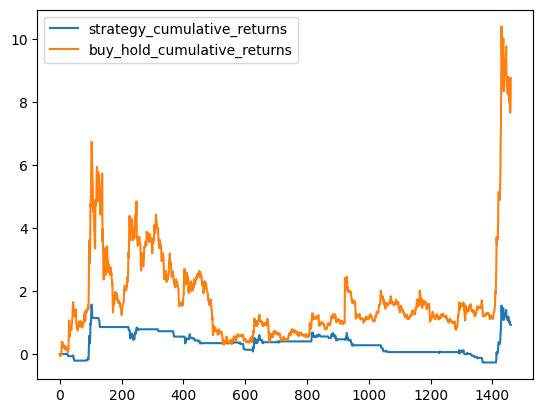

In [32]:
backtest_results.get('results').get('ripple')[['strategy_cumulative_returns', 'buy_hold_cumulative_returns']].plot()

In [34]:
data = backtest_results.get('signals').get('ethereum')
#data['date'] = pd.to_datetime(data['date'])
data

,date,open,close,final_decision_shifted,usd_trend_signal,btc_trend_signal,rsi_usd_signal,rsi_btc_signal,volatility_signal,ssr_signal
0,2021-01-01,737.82,730.15,0.0,-1,-1,1,-1,-1,-1
1,2021-01-02,729.63,777.70,0.0,-1,-1,1,-1,-1,-1
2,2021-01-03,777.23,967.00,0.0,-1,-1,1,-1,-1,-1
3,2021-01-04,970.80,1025.65,0.0,-1,-1,1,1,-1,-1
4,2021-01-05,1022.87,1103.36,0.0,-1,-1,1,1,-1,-1
...,...,...,...,...,...,...,...,...,...,...
1456,2024-12-27,3331.43,3328.61,0.0,-1,-1,-1,-1,1,-1
1457,2024-12-28,3327.95,3397.83,0.0,-1,-1,-1,-1,1,-1
1458,2024-12-29,3394.93,3357.33,0.0,-1,-1,-1,-1,1,-1
1459,2024-12-30,3347.85,3359.51,0.0,-1,-1,-1,-1,1,-1


In [23]:
backtest_results.get('trades').get('bitcoin').head(5)

,trade_id,asset,entry_date,exit_date,holding_days,entry_price,exit_price,price_return,entry_value,entry_cost,exit_value,exit_cost,trade_return,is_open
0,1,bitcoin,2021-01-18,2021-01-22,4,35750.0,30802.0,-13.84%,9990.000000,-10.000000,8598.720784,-8.607328,-13.93%,False
1,2,bitcoin,2021-01-25,2021-01-28,3,32263.0,30537.0,-5.35%,8590.122063,-8.598721,8122.438734,-8.130569,-18.71%,False
2,3,bitcoin,2021-02-13,2021-02-17,4,47399.0,49211.0,3.82%,8114.316295,-8.122439,8416.091175,-8.424516,-15.77%,False
3,4,bitcoin,2021-03-06,2021-03-08,2,49051.0,51174.0,4.33%,8407.675084,-8.416091,8762.800154,-8.771572,-12.30%,False
4,5,bitcoin,2021-03-18,2021-03-23,5,59269.0,54241.0,-8.48%,8754.037354,-8.762800,8003.389839,-8.011401,-19.90%,False


In [25]:
backtest_results.get('metrics').get('bitcoin').head(5)

,total_return_pct,max_drawdown_pct,sharpe_ratio,sortino_ratio,annualized_volatility_pct,annualized_return_pct,total_trades,win_rate,avg_win,avg_loss,profit_factor,total_transaction_costs
0,94.726445,46.495139,0.037362,0.036459,24.400913,15.567141,73,54.794521,37.276,-17.859697,2.529888,1629.695544


In [26]:
backtest_results.keys()

dict_keys(['results', 'signals', 'trades', 'metrics', 'basket_selection'])

In [27]:
backtest_results.get('strategy_metrics'), backtest_results.get('buy_hold_metrics')

(None, None)

In [28]:
backtest_results.get('trades_metrics')

In [ ]:
#['results_df', 'signals_df', 'metrics_df', 'trades_df', 'trade_metrics', 'strategy_metrics', 'buy_hold_metrics']
backtest_results.get('trades_df')

In [ ]:
backtest_results.get('signals_df')['volatility_signal'].plot()

In [ ]:
# Get table of recommended assets
backtest_results = analyzer.backtest_portfolio('btc_trend_follower', '2022-01-01', '2022-12-31')
recommendations = analyzer.get_recommended_assets_table(backtest_results)
print(recommendations.head())

In [ ]:
# Plot trend distribution for Bitcoin
fig = analyzer.plot_trend_distribution('bitcoin', trend_type='USD', show_plot=True)

In [ ]:
# Plot the transition matrix for Ethereum
fig = analyzer.plot_trend_distribution('solana', trend_type='BTC')

In [15]:
analyzer.clear_cache()

In [ ]:
analyzer.get_ticker_from_id('cardano')